# Simple Clustering Demo 

**Goal:** Group **store locations** (given only `x_coord`, `y_coord`) into natural clusters — **without** being told the answer in advance.

This is **unsupervised learning**: unlike classification/regression, there is no `y` (target) column to predict. The algorithm just finds patterns/groups in the data on its own.

We will use `store_locations.csv` (make sure it's in the same folder as this notebook) and the **K-Means** algorithm, the most common beginner clustering method.

## Step 1: Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

## Step 2: Load the dataset

In [2]:
df = pd.read_csv('store_locations.csv')
df.head()

,x_coord,y_coord
0,2.87,7.62
1,1.62,1.89
2,1.43,1.11
3,2.59,8.73
4,1.48,8.70


## Step 3: Visualize the raw (unlabeled) data

Notice: no colors, no categories — just points. Our eyes can spot ~3 groups, but the algorithm doesn't know that yet.

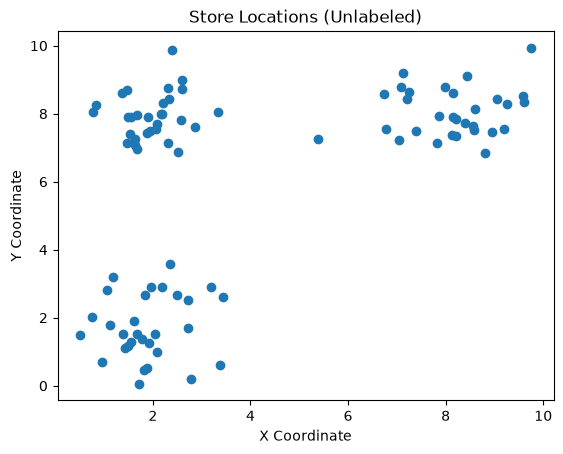

In [3]:
plt.scatter(df['x_coord'], df['y_coord'])
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Store Locations (Unlabeled)')
plt.show()

## Step 4: Use the Elbow Method to choose the number of clusters (k)

K-Means needs to be told **how many** clusters (`k`) to find. The elbow method helps pick a good value: we try several values of k and plot the "inertia" (how tightly grouped the points are). The point where the curve bends like an elbow is usually a good choice.

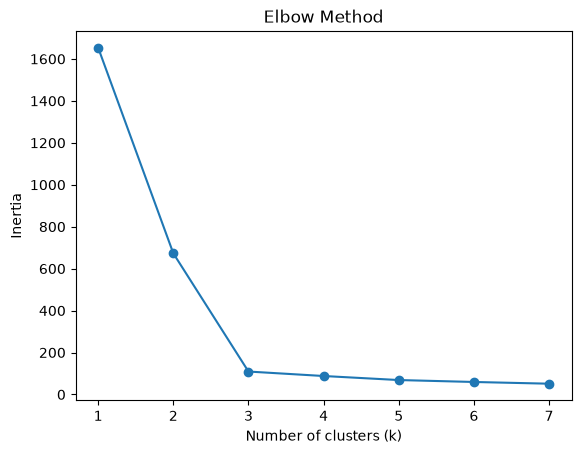

In [4]:
inertias = []
k_values = range(1, 8)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df[['x_coord', 'y_coord']])
    inertias.append(km.inertia_)

plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

The curve bends sharply around **k = 3**, so that's the value we'll use.

## Step 5: Train the K-Means model with k = 3

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df[['x_coord', 'y_coord']])
df.head()

,x_coord,y_coord,cluster
0,2.87,7.62,2
1,1.62,1.89,1
2,1.43,1.11,1
3,2.59,8.73,2
4,1.48,8.70,2


## Step 6: Visualize the clusters

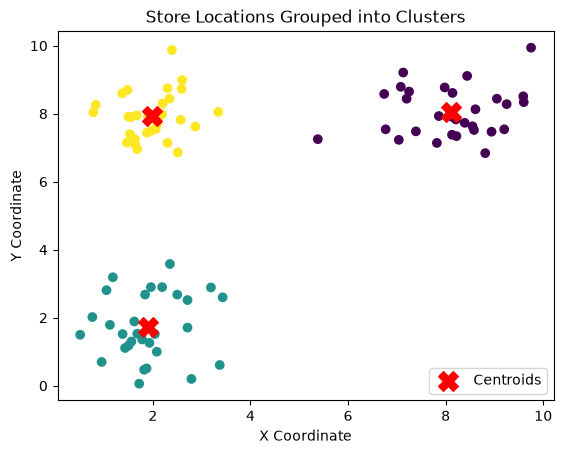

In [6]:
plt.scatter(df['x_coord'], df['y_coord'], c=df['cluster'], cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Store Locations Grouped into Clusters')
plt.legend()
plt.show()

## Step 7: Inspect the clusters

In [7]:
df['cluster'].value_counts().sort_index()

cluster
0    30
1    30
2    30
Name: count, dtype: int64

In [8]:
df.groupby('cluster')[['x_coord', 'y_coord']].mean()

,x_coord,y_coord
cluster,,
0,8.108000,8.051667
1,1.900667,1.733000
2,1.979000,7.928000


## Step 8: Assign a brand-new point to a cluster

Try changing the coordinates below and re-running to see which cluster it falls into.

In [9]:
new_point = pd.DataFrame({'x_coord': [7.5], 'y_coord': [7.8]})
predicted_cluster = kmeans.predict(new_point)[0]
print(f'This point belongs to cluster: {predicted_cluster}')

This point belongs to cluster: 0


### Summary
- **Clustering** = grouping data points by similarity, with **no target labels** given (unsupervised learning).
- We used **K-Means**, which needs `k` (number of clusters) chosen in advance — the **elbow method** helps pick a good value.
- No accuracy/R² here since there's no "correct answer" to compare against; instead we visually inspect the clusters and look at metrics like **inertia**.